In [11]:
import pickle
from pathlib import Path
import pandas as pd
from IPython.display import display, Image

# --- CONFIGURATION ---
PROJECT_ROOT = Path.cwd().parent 
PROCESSED_DATA_DIR = PROJECT_ROOT / "processed_data"

# --- Load the data ---
try:
    with open(PROCESSED_DATA_DIR / "texts.pkl", "rb") as f:
        texts = pickle.load(f)
    with open(PROCESSED_DATA_DIR / "image_paths.pkl", "rb") as f:
        image_paths = pickle.load(f)
    print(f"✅ Successfully loaded {len(texts)} text chunks and {len(image_paths)} images.")
except FileNotFoundError:
    print("❌ Data not found. Please run data_processor.py first.")

✅ Successfully loaded 172 text chunks and 55 images.


In [12]:
# Convert the list of text chunk dictionaries to a Pandas DataFrame
df_texts = pd.DataFrame(texts)

# Display the first 10 text chunks
print("--- First 10 Text Chunks ---")
display(df_texts.head(10))

--- First 10 Text Chunks ---


,text,source_page
0,# COMPUTER NETWORKS– V SEM CSE VTU,1
1,# CONTENTS: MODULE -1,1
2,# 1. DATA COMMUNICATIONS \n1.1. Components \n* 1.2. Data Representation\n1.3. Data Flow,1
3,# 2. NETWORKS \n2.1. Network Criteria \n2.2. Physical Structures,1
4,# 3. NETWORK TYPES \n3.1. Local Area Network \n* 3.2. Wide Area Network\n* 3.3. Switching\n* 3.4. The Internet,1
5,## 3.5. Accessing the Internet,1
6,# 4. PROTOCOL LAYERING \n* 4.1. Scenarios\n* 4.2. Principles of Protocol Layering\n* 4.3. Logical Connections,1
7,# 5. TCP/IP PROTOCOL SUITE \n* 5.1. Layered Architecture\n* 5.2. Layers in the TCP/IP Protocol Suite\n* 5.3. Description of Each Layer\n* 5.4. Encapsulation and Decapsulation\n* 5.5. Addressing\n5.6. Multiplexing and Demultiplexing \n* 6. TRANSMISSION MEDIA,1
8,## 6.1. GUIDED MEDIA \n* 6.2. Twisted-Pair Cable\n* 6.3. Coaxial Cable\n* 6.4. Fiber-Optic Cable\n* 7. UNGUIDED MEDIA: WIRELESS\n7.1. Radio Waves \n* 7.2. Microwaves\n* 7.3. Infrared\n* 8. PACKET SWITCHING\n* 8.1. Datagram Networks\n8.2. Virtual-Circuit Networks,1
9,# MODULE-1: Data Communications & Networks,2


In [13]:
# --- Snippet to see full text (Option 1) ---
# Set the max column width to None to display full content
pd.set_option('display.max_colwidth', None)

# Now, display the DataFrame again
display(df_texts.head(10))

,text,source_page
0,# COMPUTER NETWORKS– V SEM CSE VTU,1
1,# CONTENTS: MODULE -1,1
2,# 1. DATA COMMUNICATIONS \n1.1. Components \n* 1.2. Data Representation\n1.3. Data Flow,1
3,# 2. NETWORKS \n2.1. Network Criteria \n2.2. Physical Structures,1
4,# 3. NETWORK TYPES \n3.1. Local Area Network \n* 3.2. Wide Area Network\n* 3.3. Switching\n* 3.4. The Internet,1
5,## 3.5. Accessing the Internet,1
6,# 4. PROTOCOL LAYERING \n* 4.1. Scenarios\n* 4.2. Principles of Protocol Layering\n* 4.3. Logical Connections,1
7,# 5. TCP/IP PROTOCOL SUITE \n* 5.1. Layered Architecture\n* 5.2. Layers in the TCP/IP Protocol Suite\n* 5.3. Description of Each Layer\n* 5.4. Encapsulation and Decapsulation\n* 5.5. Addressing\n5.6. Multiplexing and Demultiplexing \n* 6. TRANSMISSION MEDIA,1
8,## 6.1. GUIDED MEDIA \n* 6.2. Twisted-Pair Cable\n* 6.3. Coaxial Cable\n* 6.4. Fiber-Optic Cable\n* 7. UNGUIDED MEDIA: WIRELESS\n7.1. Radio Waves \n* 7.2. Microwaves\n* 7.3. Infrared\n* 8. PACKET SWITCHING\n* 8.1. Datagram Networks\n8.2. Virtual-Circuit Networks,1
9,# MODULE-1: Data Communications & Networks,2


In [16]:
# --- Snippet to see full text (Option 2) ---
# Get the full text from the chunk at index 1
full_text = df_texts.loc[11, 'text']

print(full_text)

## 1.1. Components  
A data communication system includes the following components:  
* 1. Message: The data or information being communicated (e.g., text, images, audio).
* 2. Sender: The device that sends the message, such as a computer or smartphone.
* 3. Receiver: The device that receives the message, like another computer or a printer.
* 4. Transmission Medium: The physical path through which the data is transmitted, like cables or radio waves.
* 5. Protocol: A set of rules that governs the communication between devices to ensure proper data exchange.
The performance of a data communication system relies on four key characteristics: delivery, accuracy, timeliness, and jitter.  
* 1. Delivery: The system must ensure that data reaches the correct destination. Only the intended recipient—whether a device or a user—should receive the data.
* 2. Accuracy: Data must be transmitted without errors. If data is altered during transmission and not corrected, it becomes unusable.
* 3. Timelin


--- First 5 Extracted Images ---
Image Path: C:\Users\karth\CogniVerse\processed_data\images\page_2_img_679bf258.jpeg


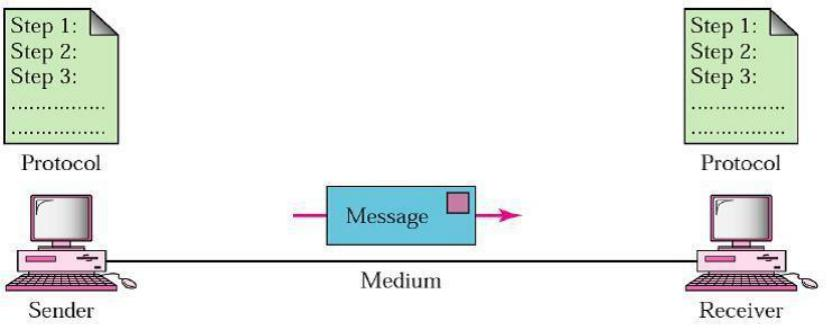

Image Path: C:\Users\karth\CogniVerse\processed_data\images\page_4_img_31f61477.jpeg


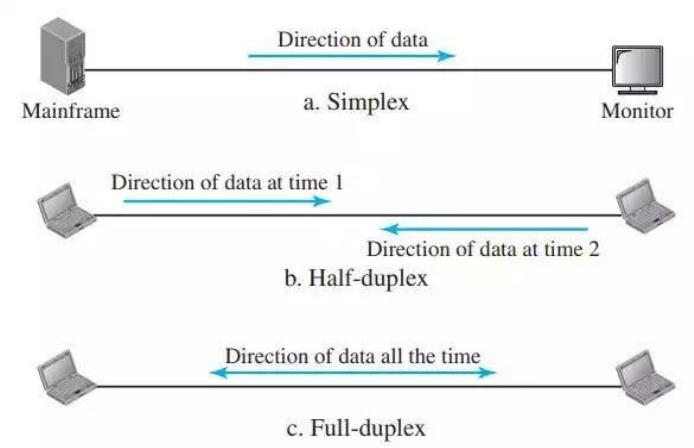

Image Path: C:\Users\karth\CogniVerse\processed_data\images\page_5_img_a8b06641.jpeg


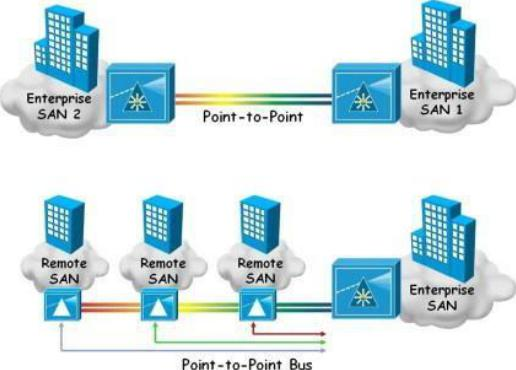

Image Path: C:\Users\karth\CogniVerse\processed_data\images\page_6_img_ca998b00.jpeg


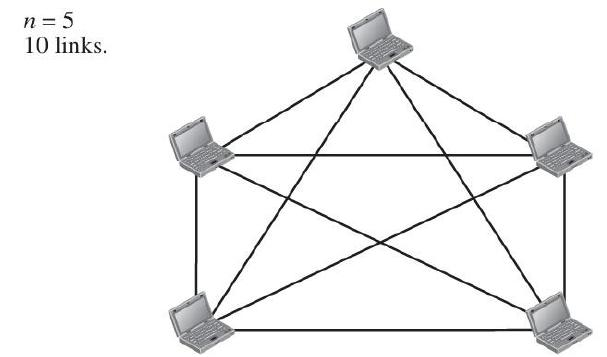

Image Path: C:\Users\karth\CogniVerse\processed_data\images\page_6_img_a280d723.jpeg


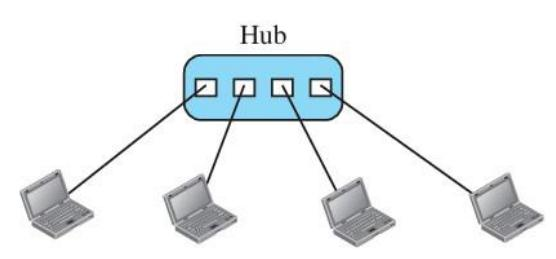

In [15]:
# Display the first 5 extracted images
print("\n--- First 5 Extracted Images ---")
for path in image_paths[:5]:
    print(f"Image Path: {path}")
    display(Image(filename=path, width=400)) # Adjust width as needed

In [17]:
import pickle
from pathlib import Path
import pandas as pd
from IPython.display import display, Image
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

# --- CONFIGURATION ---
PROJECT_ROOT = Path.cwd().parent 
PROCESSED_DATA_DIR = PROJECT_ROOT / "processed_data"
VECTOR_STORE_PATH = PROJECT_ROOT / "vector_store_chroma"
EMBEDDING_MODEL = "BAAI/bge-large-en-v1.5"
ID_KEY = "doc_id"

# --- Load the Vector Store ---
print("Loading vector store...")
vectorstore = Chroma(
    collection_name="cogniverse-final-v7", # Make sure this matches your app's collection name
    embedding_function=HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL),
    persist_directory=str(VECTOR_STORE_PATH)
)
print(f"✅ Vector store loaded with {vectorstore._collection.count()} summaries.")

# --- Load the Original Documents (the Docstore) ---
print("\nLoading original processed data...")
try:
    with open(PROCESSED_DATA_DIR / "texts.pkl", "rb") as f: texts = pickle.load(f)
    with open(PROCESSED_DATA_DIR / "tables.pkl", "rb") as f: tables = pickle.load(f)
    # Images are not needed for this text-focused inspection
    
    # Create a simple dictionary to act as our docstore {doc_id: full_text}
    docstore = {}
    
    # We need to recreate the placeholder IDs in the same order as the app did
    all_text_docs = [t['text'] for t in texts] + [t['html'] for t in tables]
    for i, doc_content in enumerate(all_text_docs):
        doc_id = str(i) # This assumes simple integer IDs were used in order
        docstore[doc_id] = doc_content
        
    print(f"✅ Reconstructed docstore with {len(docstore)} full-text documents.")

except FileNotFoundError:
    print("❌ Data not found. Please ensure data_processor.py and cogniverse_app.py have been run.")
except Exception as e:
    print(f"An error occurred: {e}")

Loading vector store...


c:\Users\karth\anaconda3\envs\cogniverse_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Vector store loaded with 225 summaries.

Loading original processed data...
✅ Reconstructed docstore with 175 full-text documents.


In [18]:
def inspect_retrieval(query: str, k: int = 5):
    """
    Performs a vector search and displays the retrieved summaries alongside their
    original full-text documents for comparison.
    """
    print(f"\n{'='*20}\nINSPECTING QUERY: '{query}'\n{'='*20}")
    
    # 1. Search the vector store for the top k summaries
    retrieved_summaries = vectorstore.similarity_search_with_score(query, k=k)
    
    if not retrieved_summaries:
        print("\n❌ Retrieval FAILED. No relevant summaries were found.")
        return
        
    print(f"\n✅ Retrieval SUCCESS. Found {len(retrieved_summaries)} results:")
    
    # 2. For each summary, find the full text and display the comparison
    for i, (summary_doc, score) in enumerate(retrieved_summaries):
        summary_text = summary_doc.page_content
        doc_id = summary_doc.metadata.get(ID_KEY)
        
        print(f"\n--- Result {i+1} (Score: {score:.4f}) ---")
        print(f"📄 SUMMARY:\n{summary_text}")
        print("-" * 15)
        
        if doc_id and doc_id in docstore:
            full_text = docstore[doc_id]
            print(f"📖 ORIGINAL FULL TEXT (ID: {doc_id}):\n{full_text}")
        else:
            print(f"⚠️ Could not find original full text for ID: {doc_id}")
            
        print("-" * 40)

In [19]:
# Test the query that is failing
inspect_retrieval("what are the components of data communication")


INSPECTING QUERY: 'what are the components of data communication'

✅ Retrieval SUCCESS. Found 5 results:

--- Result 1 (Score: 0.2975) ---
📄 SUMMARY:
Data communication system components include message, sender, receiver, medium, and protocol; performance is measured by delivery, accuracy, timeliness, and jitter.
---------------
⚠️ Could not find original full text for ID: 0506cf21-47e4-42c9-9ebd-4f320919cbad
----------------------------------------

--- Result 2 (Score: 0.3163) ---
📄 SUMMARY:
Data communication is the process of transferring data between points using a communication system, encompassing key components and mechanisms.
---------------
⚠️ Could not find original full text for ID: a9ecf673-3740-4f8f-8523-c7628f81aa97
----------------------------------------

--- Result 3 (Score: 0.4685) ---
📄 SUMMARY:
An outline of module 1 covering data communications components, representation, and flow.
---------------
⚠️ Could not find original full text for ID: 5f3deeb8-be44-46d8-b6